# Week 1
## Assignment 1 Netflix Viewership

In [128]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [129]:
# Open the files

netflix_popular_df = pd.read_excel(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/most-popular-netflix.xlsx"
)
netflix_countries_df = pd.read_excel(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/all-weeks-countries-netflix.xlsx"
)
netflix_global_df = pd.read_excel(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DCS 640/all-weeks-global-netflix.xlsx"
)

In [130]:
# display column names for easy reference

print(netflix_popular_df.columns)

Index(['category', 'rank', 'show_title', 'season_title',
       'hours_viewed_first_91_days', 'runtime', 'views_first_91_days'],
      dtype='object')


In [131]:
print(netflix_global_df.columns)

Index(['week', 'category', 'weekly_rank', 'show_title', 'season_title',
       'weekly_hours_viewed', 'runtime', 'weekly_views',
       'cumulative_weeks_in_top_10', 'is_staggered_launch',
       'episode_launch_details'],
      dtype='object')


In [132]:
netflix_popular_df.head()

,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
0,Films (English),1,Red Notice,NaN,454200000,1.9667,230900000
1,Films (English),2,Don't Look Up,NaN,408600000,2.3833,171400000
2,Films (English),3,The Adam Project,NaN,281000000,1.7833,157600000
3,Films (English),4,Bird Box,NaN,325300000,2.0667,157400000
4,Films (English),5,Leave the World Behind,NaN,339300000,2.3667,143400000


In [133]:
netflix_countries_df.head()

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2024-04-14,Films,1,The Tearsmith,NaN,2
1,Argentina,AR,2024-04-14,Films,2,Stolen,NaN,1
2,Argentina,AR,2024-04-14,Films,3,"Love, Divided",NaN,1
3,Argentina,AR,2024-04-14,Films,4,Woody Woodpecker Goes to Camp,NaN,1
4,Argentina,AR,2024-04-14,Films,5,Rest In Peace,NaN,3


In [134]:
netflix_global_df.head()

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2024-04-14,Films (English),1,What Jennifer Did,NaN,26100000,1.4500,18000000.0,1,False,NaN
1,2024-04-14,Films (English),2,Woody Woodpecker Goes to Camp,NaN,19600000,1.6667,11800000.0,1,False,NaN
2,2024-04-14,Films (English),3,Scoop,NaN,14600000,1.7167,8500000.0,2,False,NaN
3,2024-04-14,Films (English),4,Glass,NaN,11000000,2.1500,5100000.0,2,False,NaN
4,2024-04-14,Films (English),5,Megan Leavey,NaN,9700000,1.9333,5000000.0,1,False,NaN


In [135]:
# define color mappings for the categories

category_colors = {
    'TV (English)': 'lightblue', 
    'TV (Non-English)': 'lightblue', 
    'Films (English)': 'darkblue', 
    'Films (Non-English)': 'darkblue'
}

In [136]:
# Group data by category and calculate the total hours 
# viewed in the first 91 days to show TV is higher than film

grouped_popular_data = netflix_popular_df.groupby('category') \
    ['hours_viewed_first_91_days'].sum()

In [137]:
# Get the color mapping for each category

colors = [category_colors[category] for category in grouped_popular_data.index]

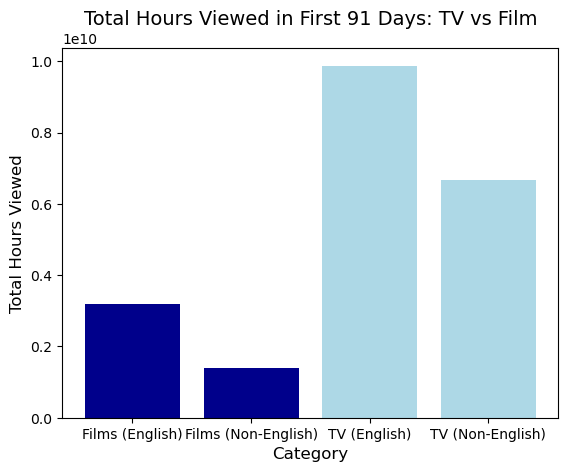

In [138]:
# Plot a bar chart

plt.bar(grouped_popular_data.index, grouped_popular_data.values, color=colors)

# Add titles and labels

plt.title('Total Hours Viewed in First 91 Days: TV vs Film', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Hours Viewed', fontsize=12)

# Show the bar chart

plt.show()

In [139]:
# define color mappings for the categories

category_colors = {
    'TV (English)': 'lightblue', 
    'TV (Non-English)': 'lightblue', 
    'Films (English)': 'darkblue', 
    'Films (Non-English)': 'darkblue'
}

In [140]:
# Group data by category and calculate the average cumulative weeks in Top 10

average_global_data = netflix_global_df.groupby('category') \
    ['cumulative_weeks_in_top_10'].mean()

In [141]:
# Define categories in the desired order

categories=['TV (English)', 'TV (Non-English)', 'Films (English)', 'Films (Non-English)']

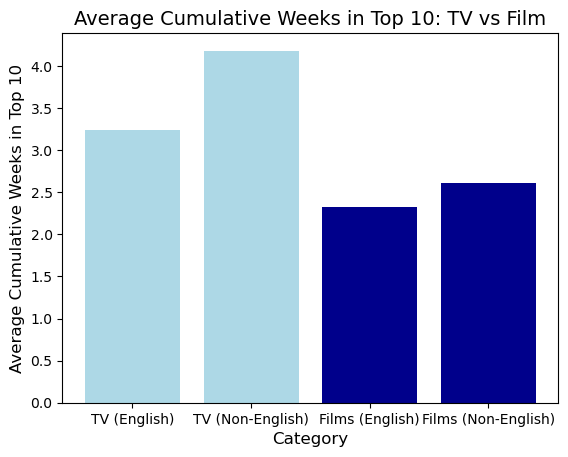

In [142]:
# Plot a bar chart

# get averages
averages = [
    average_global_data['TV (English)'],
    average_global_data['TV (Non-English)'],
    average_global_data['Films (English)'],
    average_global_data['Films (Non-English)']
]

# Get the color mapping for each category
colors = [category_colors[category] for category in categories]

plt.bar(categories, averages, color=colors)

# Add labels and title

plt.title('Average Cumulative Weeks in Top 10: TV vs Film', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Cumulative Weeks in Top 10', fontsize=12)

# Display the chart

plt.show()

In [143]:
# Group data by 'country' and 'category'

average_country_data = netflix_countries_df.groupby(['country_name', 'category']) \
    ['cumulative_weeks_in_top_10'].mean()

In [144]:
# Reshape data for plotting so Film and TV become categories
# category values are now columns

average_country_data = average_country_data.unstack('category') 

In [145]:
# Select top 10 countries based on the total cumulative weeks across both categories

# add a Total column
average_country_data['Total']=average_country_data['TV']+average_country_data['Films']  

# select top 10 based on 'Total'
top_countries = average_country_data.nlargest(10, columns='Total')  

# drop Total column before plotting
average_country_data = top_countries.drop(columns='Total') 

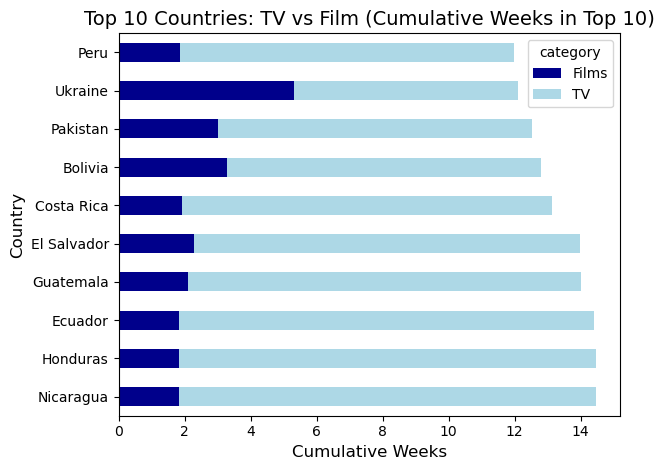

In [146]:
# plot a horizontal bar chart

average_country_data.plot(kind='barh', stacked=True, color=['darkblue', 'lightblue'])
plt.title('Top 10 Countries: TV vs Film (Cumulative Weeks in Top 10)', fontsize=14)
plt.xlabel('Cumulative Weeks', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.tight_layout()
plt.show()

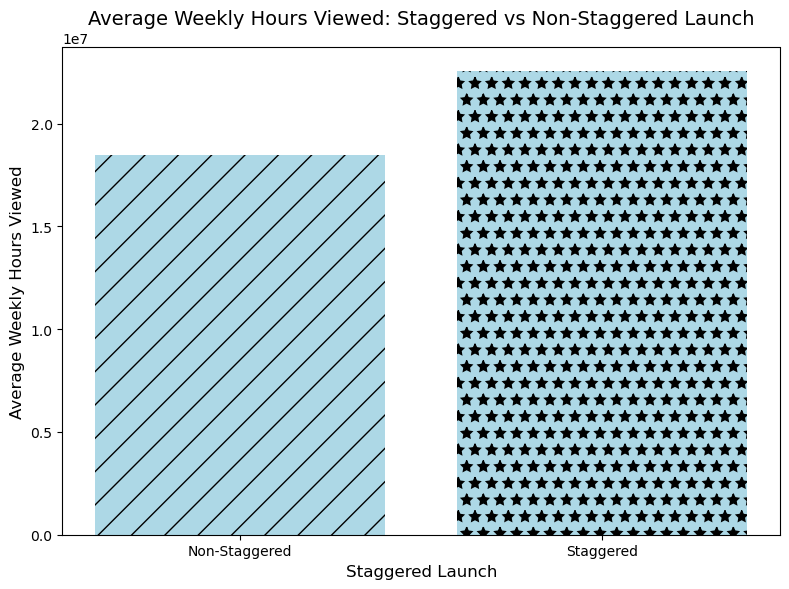

In [147]:
# staggered launch effect on weekly hours viewed

# Group data by 'is_staggered_launch' and calculate the average weekly hours viewed
staggered_avg_hours_viewed = netflix_global_df.groupby('is_staggered_launch') \
    ['weekly_hours_viewed'].mean()

# define bar patterns
patterns = ['/', '*'] 

# Create a bar plot
fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(
    staggered_avg_hours_viewed.index,staggered_avg_hours_viewed.values,color='lightblue'
)

# add patterns to each bar
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

# Customize the plot
plt.title('Average Weekly Hours Viewed: Staggered vs Non-Staggered Launch', fontsize=14)
plt.ylabel('Average Weekly Hours Viewed', fontsize=12)
plt.xlabel('Staggered Launch', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Staggered', 'Staggered'], rotation=0)  
plt.tight_layout()

# Show the plot
plt.show()


In [148]:
# Convert 'week' to date time

netflix_global_df['week'] = pd.to_datetime(netflix_global_df['week'])

In [149]:
# Group data by week and category
# category values are now columns

weekly_global_data = netflix_global_df.groupby(['week', 'category']) \
    ['weekly_hours_viewed'].sum().unstack('category')

In [150]:
# Separate data for TV and Films

# check if the categories exist in the dataframe
tv_data = (
    weekly_global_data[['TV (English)', 'TV (Non-English)']] 
    if 'TV (English)' in weekly_global_data 
    else None
)
film_data = (
    weekly_global_data[['Films (English)', 'Films (Non-English)']] 
    if 'Films (English)' in weekly_global_data 
    else None
)

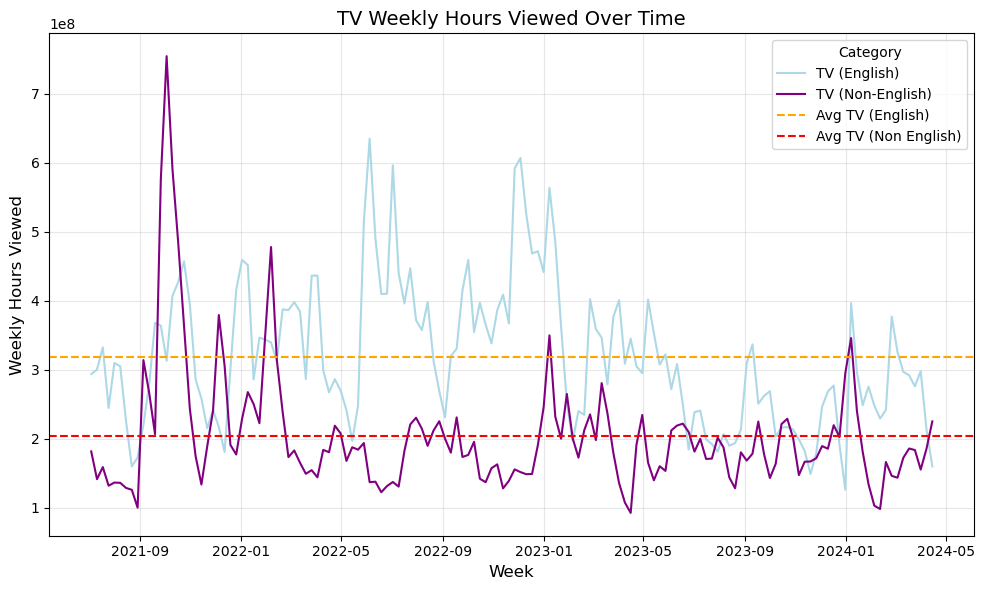

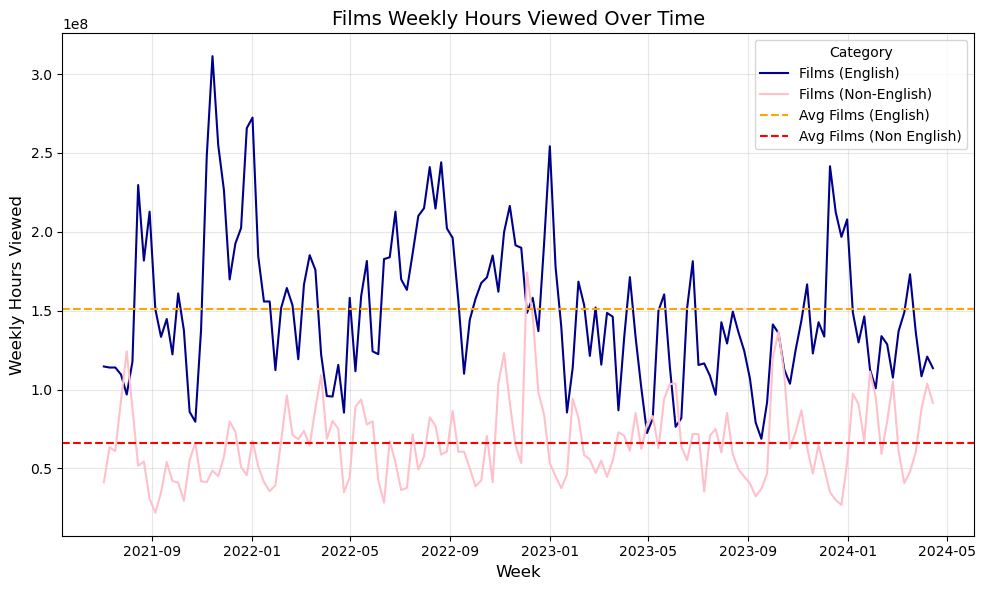

In [151]:
# Plot the line graphs

# Plot TV weekly hours viewed over time

# Calculate the average for TV (English) and TV (Non-English)
tv_english_avg = tv_data['TV (English)'].mean()
tv_non_english_avg = tv_data['TV (Non-English)'].mean()

# Calculate the average for Films (English) and Films (Non-English)
films_english_avg = film_data['Films (English)'].mean()
films_non_english_avg = film_data['Films (Non-English)'].mean()

if tv_data is not None:
    plt.figure(figsize=(10, 6))
    plt.plot(
        tv_data.index, 
        tv_data['TV (English)'], 
        label='TV (English)', 
        color='lightblue'
    )
    plt.plot(
        tv_data.index, 
        tv_data['TV (Non-English)'], 
        label='TV (Non-English)', 
        color='purple'
    )

    # Add average lines
    plt.axhline(
        y=tv_english_avg, 
        color='orange', 
        linestyle='--', 
        label='Avg TV (English)'
    )
    plt.axhline(
        y=tv_non_english_avg, 
        color='red', 
        linestyle='--', 
        label='Avg TV (Non English)'
    )
    
    plt.title('TV Weekly Hours Viewed Over Time', fontsize=14)
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Weekly Hours Viewed', fontsize=12)
    plt.legend(title='Category', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot Films weekly hours viewed over time
if film_data is not None:
    plt.figure(figsize=(10, 6))
    plt.plot(
        film_data.index, 
        film_data['Films (English)'], 
        label='Films (English)', 
        color='darkblue'
    )
    plt.plot(
        film_data.index, 
        film_data['Films (Non-English)'], 
        label='Films (Non-English)', 
        color='pink'
    )

    # Add average lines
    plt.axhline(
        y=films_english_avg, 
        color='orange', 
        linestyle='--',
        label='Avg Films (English)'
    )
    plt.axhline(
        y=films_non_english_avg, 
        color='red', 
        linestyle='--', 
        label='Avg Films (Non English)'
    )

    
    plt.title('TV Weekly Hours Viewed Over Time', fontsize=14)
    plt.title('Films Weekly Hours Viewed Over Time', fontsize=14)
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Weekly Hours Viewed', fontsize=12)
    plt.legend(title='Category', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
